In [8]:
%pip install matplotlib


  Using cached contourpy-1.3.1-cp310-cp310-win_amd64.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.7-cp310-cp310-win_amd64.whl.metadata (6.4 kB)
  Using cached pillow-11.0.0-cp310-cp310-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.2.0-py3-none-any.whl.metadata (5.0 kB)
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 4.2 MB/s eta 0:00:02
   ------ --------------------------------- 1.3/8.0 MB 3.7 MB/s eta 0:00:02
   ---------- ----------------------------- 2.1/8.0 MB 3.7 MB/s eta 0:00:02
   -------------- ------------------------- 2.9/8.0 MB 3.6 MB/s eta 0:00:02
   ------------------ --------------------- 3.7/8.0 MB 3.6 MB/s eta 0:00:02
   ---------------------- ----------------- 4.5/8.0 MB 3.6 MB/s eta 0:00:01
   -------------------------- ------------- 5.2/8.0 MB 3.6 MB/s eta 0:00:01
   ------------------------------ --------- 6

In [1]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.


In [23]:
%pip install tensorflow-addons

  Using cached tensorflow_addons-0.22.0-cp310-cp310-win_amd64.whl.metadata (1.8 kB)
  Using cached typeguard-2.13.3-py3-none-any.whl.metadata (3.6 kB)
Using cached tensorflow_addons-0.22.0-cp310-cp310-win_amd64.whl (719 kB)
Using cached typeguard-2.13.3-py3-none-any.whl (17 kB)
Note: you may need to restart the kernel to use updated packages.


In [31]:
%pip install scikit-learn

  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached threadpoolctl-3.5.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 3.3 MB/s eta 0:00:04
   --- ------------------------------------ 1.0/11.1 MB 3.6 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/11.1 MB 3.6 MB/s eta 0:00:03
   --------- ------------------------------ 2.6/11.1 MB 3.6 MB/s eta 0:00:03
   ------------ --------------------------- 3.4/11.1 MB 3.5 MB/s eta 0:00:03
   ------------- -------------------------- 3.7/11.1 MB 3.6 MB/s eta 0:00:03
   ---------------- ----------------------- 4.7/11.1 MB 3.4 MB/s eta 0:00:02
   ------------------- -------------------- 5.5/11.1 MB 3.5 MB/s eta 0:00:02
   ---------------------- ----------------- 6.3/11.1 MB 3.5 MB/s eta 0:00:02
   ------------------------- -------------- 7.1/11.1 MB 3.5 MB/s eta 0:00:02
   -------------------------

In [32]:
import tensorflow as tf
import os
import random
import cv2
import imghdr
import numpy as np
from matplotlib import pyplot as plt # type: ignore
import PIL # type: ignore
import pathlib
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, UpSampling2D, SpatialDropout2D,concatenate # type: ignore
from tensorflow.keras.models import Model # type: ignore
from tensorflow.keras.callbacks import ModelCheckpoint,ReduceLROnPlateau # type: ignore
from tensorflow.keras.models import load_model # type: ignore
from keras import layers
from keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras import layers, models, regularizers # type: ignore
from keras.utils import to_categorical
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy # type: ignore
from tensorflow_addons.metrics import F1Score # type: ignore
from PIL import Image # type: ignore
from tensorflow.keras.preprocessing.image import img_to_array # type: ignore
from tensorflow.keras.applications.vgg16 import preprocess_input, decode_predictions # type: ignore
from tensorflow.keras.layers import Rescaling # type: ignore
from sklearn.model_selection import train_test_split # type: ignore


In [33]:
import tensorflow as tf # type: ignore
tf.keras.backend.clear_session()

import tensorflow as tf # type: ignore

print("TensorFlow version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available:", [gpu.name for gpu in gpus])
else:
    print("No GPU detected. TensorFlow will run on CPU.")

TensorFlow version: 2.10.1
GPU is available: ['/physical_device:GPU:0']


In [52]:
image_dir='E:/Msa/pattern recognition/Project/Water Bodies Code/Water Bodies Dataset/Images'
label_dir='E:/Msa/pattern recognition/Project/Water Bodies Code/Water Bodies Dataset/Masks'

In [35]:
%pip install rasterio

   ---------------------------------------- 0.0/25.4 MB ? eta -:--:--
   ---------------------------------------- 0.3/25.4 MB ? eta -:--:--
    --------------------------------------- 0.5/25.4 MB 2.8 MB/s eta 0:00:09
   - -------------------------------------- 1.0/25.4 MB 2.4 MB/s eta 0:00:11
   --- ------------------------------------ 2.1/25.4 MB 3.0 MB/s eta 0:00:08
   ---- ----------------------------------- 2.6/25.4 MB 3.0 MB/s eta 0:00:08
   ---- ----------------------------------- 3.1/25.4 MB 2.7 MB/s eta 0:00:09
   ----- ---------------------------------- 3.7/25.4 MB 2.7 MB/s eta 0:00:09
   ------ --------------------------------- 3.9/25.4 MB 2.5 MB/s eta 0:00:09
   ------- -------------------------------- 4.5/25.4 MB 2.5 MB/s eta 0:00:09
   ------- -------------------------------- 5.0/25.4 MB 2.5 MB/s eta 0:00:09
   -------- ------------------------------- 5.5/25.4 MB 2.5 MB/s eta 0:00:08
   --------- ------------------------------ 6.0/25.4 MB 2.5 MB/s eta 0:00:08
   ----------

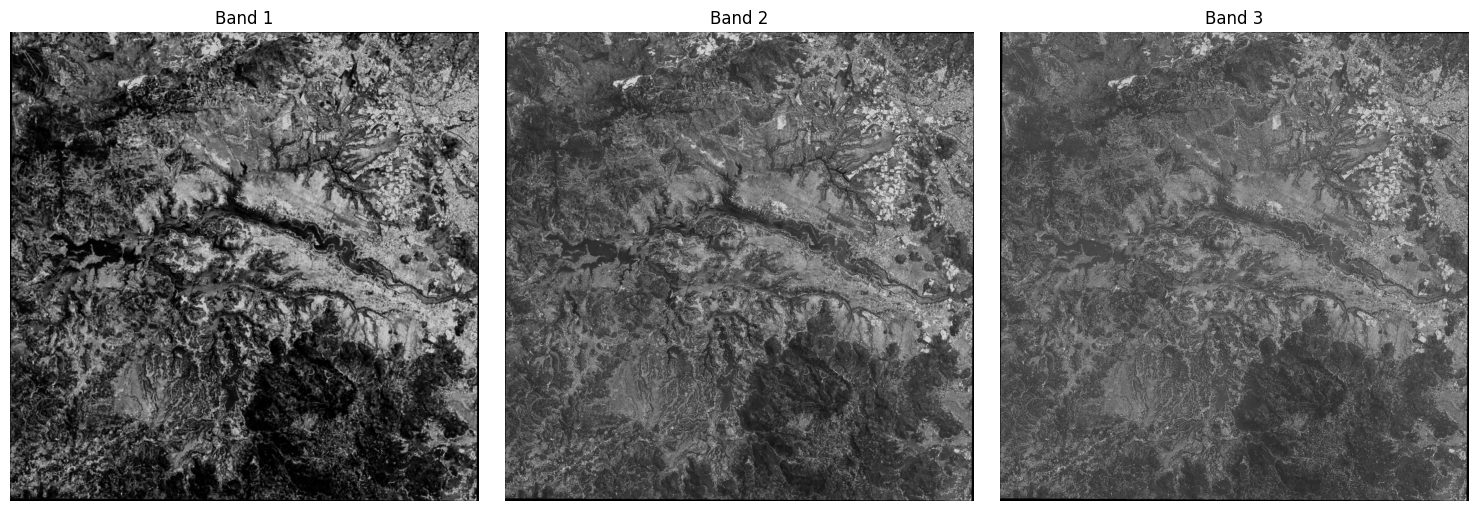

In [ ]:
import rasterio
import matplotlib.pyplot as plt

def load_image(image_path):
    with rasterio.open(image_path) as src:
        image = src.read()  # This returns a 3D array (bands, height, width)
        image = image.astype('float32')
    return image

image_path = 'E:/Msa/pattern recognition/Project/Water Bodies Code/Water Bodies Dataset/Images/water_body_1.jpg'
image = load_image(image_path)

# Create a plot for the bands (in this case, 3 bands for RGB)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))  # Only 3 bands to display
axes = axes.flatten()

# Plot each band (RGB)
for i in range(3):  # Loop only through the 3 bands
    ax = axes[i]
    ax.imshow(image[i], cmap='gray')  # Display each band in grayscale
    ax.set_title(f'Band {i+1}')
    ax.axis('off')  # Hide the axes

plt.tight_layout()
plt.show()

In [50]:
image_path = 'E:/Msa/pattern recognition/Project/Water Bodies Code/Water Bodies Dataset/Images/water_body_1.jpg'

# Open the image file
with rasterio.open(image_path) as img_src:
    # Read the image data (shape is (bands, height, width))
    image = img_src.read()

    # Check the number of bands
    print(f'Number of bands: {image.shape[0]}')

    # Access the 1st (Red), 2nd (Green), and 3rd (Blue) bands
    min_val_red = image[0].min()  # Red band (index 0)
    max_val_red = image[0].max()

    min_val_green = image[1].min()  # Green band (index 1)
    max_val_green = image[1].max()

    min_val_blue = image[2].min()  # Blue band (index 2)
    max_val_blue = image[2].max()

# Print the min and max values for each band
(min_val_red, max_val_red), (min_val_green, max_val_green), (min_val_blue, max_val_blue)

Number of bands: 3


((0, 213), (0, 203), (0, 212))

In [60]:
import numpy as np
import os
import rasterio
from PIL import Image

def normalize_band(band, min_val, max_val):
    if max_val != min_val:
        normalized_band = (band - min_val) / (max_val - min_val)
    else:
        normalized_band = np.zeros_like(band)
    return normalized_band

def replace_nan_with_value(array):
    # Replace NaNs with a specific value
    array[np.isnan(array)] = 0
    return array

def resize_image(image, target_size=(256, 256)):
    # Convert to uint8 before resizing
    image = (image * 255).astype(np.uint8)  # Scale to 0-255 and convert to uint8
    return np.array(Image.fromarray(image).resize(target_size))

# Directories containing images and labels
image_dir = 'E:/Msa/pattern recognition/Project/Water Bodies Code/Water Bodies Dataset/Images'
label_dir = 'E:/Msa/pattern recognition/Project/Water Bodies Code/Water Bodies Dataset/Masks'

# Load and normalize images
images = []
labels = []

# Load and normalize images
for img_name in sorted(os.listdir(image_dir)):
    img_path = os.path.join(image_dir, img_name)
    with rasterio.open(img_path) as img_src:
        image = img_src.read()  # Read all bands
        # Normalize each band individually
        normalized_image = np.zeros_like(image, dtype='float32')
        for band_idx in range(image.shape[0]):
            band = image[band_idx]
            min_val = np.nanmin(band)  # Use np.nanmin to handle NaN values
            max_val = np.nanmax(band)  # Use np.nanmax to handle NaN values
            band = replace_nan_with_value(band)  # Replace NaNs in the band
            normalized_image[band_idx] = normalize_band(band, min_val, max_val)
        # Transpose to (height, width, bands)
        normalized_image = np.transpose(normalized_image, (1, 2, 0))
        # Resize image to a fixed size
        normalized_image = resize_image(normalized_image)
        images.append(normalized_image)

# Load and normalize label files
for lbl_name in sorted(os.listdir(label_dir)):
    print(f"Checking label file: {lbl_name}")  # Debugging line

    lbl_path = os.path.join(label_dir, lbl_name)
    if os.path.isfile(lbl_path):  # Ensure it's a valid file
        label = Image.open(lbl_path)
        label_array = np.array(label).astype('float32')
        # Resize label to a fixed size
        label_array = resize_image(label_array)
        label_array = np.expand_dims(label_array, axis=-1)
        labels.append(label_array)
    else:
        print(f"Skipping non-file or non-mask: {lbl_path}")  # Debugging line

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Print shapes
print("Shape of images array:", images.shape)
if len(images) > 0:
    print("Shape of the first image:", images[0].shape)

print("Shape of labels array:", labels.shape)
if len(labels) > 0:
    print("Shape of the first label:", labels[0].shape)


Checking label file: water_body_1.jpg
Checking label file: water_body_10.jpg
Checking label file: water_body_100.jpg
Checking label file: water_body_1000.jpg
Checking label file: water_body_1002.jpg
Checking label file: water_body_1003.jpg
Checking label file: water_body_1004.jpg
Checking label file: water_body_1006.jpg
Checking label file: water_body_1008.jpg
Checking label file: water_body_101.jpg
Checking label file: water_body_1010.jpg
Checking label file: water_body_1011.jpg
Checking label file: water_body_1014.jpg
Checking label file: water_body_1015.jpg
Checking label file: water_body_1018.jpg
Checking label file: water_body_1019.jpg
Checking label file: water_body_102.jpg
Checking label file: water_body_1020.jpg
Checking label file: water_body_1021.jpg
Checking label file: water_body_1022.jpg
Checking label file: water_body_1023.jpg
Checking label file: water_body_1024.jpg
Checking label file: water_body_1026.jpg
Checking label file: water_body_1027.jpg
Checking label file: wat

In [61]:
print(images[0].shape) 

(256, 256, 3)


In [62]:
images.min(),images.max()

(0, 255)

In [63]:
train_images, val_images, train_labels, val_labels = train_test_split(images, labels, test_size=0.25, random_state=42)

In [64]:
test_images, val_images, test_labels, val_labels = train_test_split(val_images, val_labels, test_size=0.5, random_state=42)

Segnet

In [81]:
input_size = (128, 128, 3)  # Adjust based on your image shape
inputs = Input(input_size)

# Encoder
conv1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
pool1 = MaxPooling2D((2, 2))(conv1)

conv2 = Conv2D(128, (3, 3), activation='relu', padding='same')(pool1)
pool2 = MaxPooling2D((2, 2))(conv2)

conv3 = Conv2D(256, (3, 3), activation='relu', padding='same')(pool2)
pool3 = MaxPooling2D((2, 2))(conv3)

conv4 = Conv2D(512, (3, 3), activation='relu', padding='same')(pool3)
pool4 = MaxPooling2D((2, 2))(conv4)

# Decoder
up5 = UpSampling2D((2, 2))(pool4)
conv5 = Conv2D(512, (3, 3), activation='relu', padding='same')(up5)

up6 = UpSampling2D((2, 2))(conv5)
conv6 = Conv2D(256, (3, 3), activation='relu', padding='same')(up6)

up7 = UpSampling2D((2, 2))(conv6)
conv7 = Conv2D(128, (3, 3), activation='relu', padding='same')(up7)

up8 = UpSampling2D((2, 2))(conv7)
conv8 = Conv2D(64, (3, 3), activation='relu', padding='same')(up8)

outputs = Conv2D(1, (1, 1), activation='sigmoid')(conv8)

model = Model(inputs=[inputs], outputs=[outputs])

In [82]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4), 
              loss='binary_crossentropy', 
              metrics=['accuracy'])

# Print model summary
model.summary()

Model: "model_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 128, 128, 3)]     0         
                                                                 
 conv2d_27 (Conv2D)          (None, 128, 128, 64)      1792      
                                                                 
 max_pooling2d_12 (MaxPoolin  (None, 64, 64, 64)       0         
 g2D)                                                            
                                                                 
 conv2d_28 (Conv2D)          (None, 64, 64, 128)       73856     
                                                                 
 max_pooling2d_13 (MaxPoolin  (None, 32, 32, 128)      0         
 g2D)                                                            
                                                                 
 conv2d_29 (Conv2D)          (None, 32, 32, 256)       2951

In [77]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-7
)

In [78]:
early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10,restore_best_weights=True)

In [71]:
import os

# Create the directory if it doesn't exist
model_dir = "model_saved"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Set the file path for saving the model
model_filepath = os.path.join(model_dir, "modell-{epoch:02d}-{val_accuracy:.4f}.keras")

# Now you can use model_filepath to save your model during training

In [79]:
checkpoint = ModelCheckpoint(
    filepath=model_filepath,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [85]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split

# Directories for images and labels
image_dir = 'E:/Msa/pattern recognition/Project/Water Bodies Code/Water Bodies Dataset/Images'
label_dir = 'E:/Msa/pattern recognition/Project/Water Bodies Code/Water Bodies Dataset/Masks'

# Get image and label filenames
image_paths = [os.path.join(image_dir, fname) for fname in os.listdir(image_dir) if fname.endswith('.jpg')]
label_paths = [os.path.join(label_dir, fname) for fname in os.listdir(label_dir) if fname.endswith('.jpg')]

# Resize and normalize images to (128, 128, 3) for images and (128, 128, 1) for labels
def preprocess_image(image_path, target_size=(128, 128)):
    img = cv2.imread(image_path)
    img = cv2.resize(img, target_size)  # Resize to (128, 128)
    img = img / 255.0  # Normalize pixel values between 0 and 1
    return img  # Image is colored (3 channels)

def preprocess_label(label_path, target_size=(128, 128)):
    label = cv2.imread(label_path, cv2.IMREAD_GRAYSCALE)  # Read as grayscale
    label = cv2.resize(label, target_size)  # Resize to (128, 128)
    label = label / 255.0  # Normalize pixel values between 0 and 1
    return np.expand_dims(label, axis=-1)  # Add channel dimension for labels (1 channel)

# Preprocess all images and labels
images = np.array([preprocess_image(img_path) for img_path in image_paths])
labels = np.array([preprocess_label(label_path) for label_path in label_paths])

# Split the data into train, validation, and test sets
train_images, val_images, train_labels, val_labels = train_test_split(images, labels, test_size=0.25, random_state=42)
test_images, val_images, test_labels, val_labels = train_test_split(val_images, val_labels, test_size=0.5, random_state=42)

# Verify shapes
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Validation images shape:", val_images.shape)
print("Validation labels shape:", val_labels.shape)

Train images shape: (2130, 128, 128, 3)
Train labels shape: (2130, 128, 128, 1)
Validation images shape: (356, 128, 128, 3)
Validation labels shape: (356, 128, 128, 1)


In [86]:
history = model.fit(train_images, 
                    train_labels, 
                    validation_data=(val_images, val_labels),
                    epochs=13,
                    batch_size=32,
                    callbacks=[early_stopping,checkpoint, reduce_lr]) 

Epoch 1/13
67/67 [==============================] - ETA: 0s - loss: 0.5604 - accuracy: 0.6051
Epoch 1: val_accuracy improved from -inf to 0.67257, saving model to model_saved\modell-01-0.6726.keras
67/67 [==============================] - 37s 288ms/step - loss: 0.5604 - accuracy: 0.6051 - val_loss: 0.5027 - val_accuracy: 0.6726 - lr: 3.0000e-04
Epoch 2/13
67/67 [==============================] - ETA: 0s - loss: 0.4433 - accuracy: 0.6881
Epoch 2: val_accuracy improved from 0.67257 to 0.69527, saving model to model_saved\modell-02-0.6953.keras
67/67 [==============================] - 17s 253ms/step - loss: 0.4433 - accuracy: 0.6881 - val_loss: 0.4329 - val_accuracy: 0.6953 - lr: 3.0000e-04
Epoch 3/13
67/67 [==============================] - ETA: 0s - loss: 0.4042 - accuracy: 0.7035
Epoch 3: val_accuracy improved from 0.69527 to 0.71765, saving model to model_saved\modell-03-0.7176.keras
67/67 [==============================] - 18s 262ms/step - loss: 0.4042 - accuracy: 0.7035 - val_loss: 

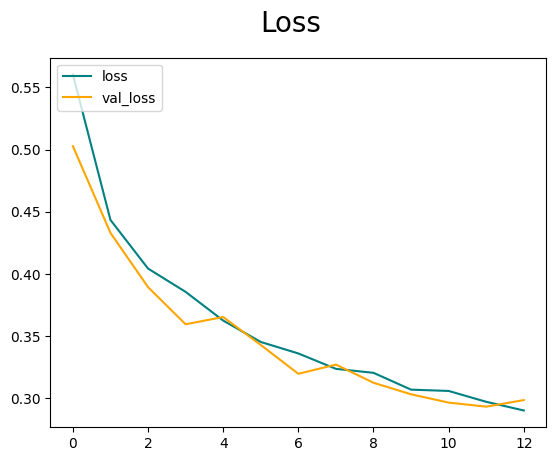

In [87]:
fig = plt.figure()
plt.plot(history.history['loss'], color='teal', label='loss')
plt.plot(history.history['val_loss'], color='orange', label='val_loss')
fig.suptitle('Loss', fontsize=20)
plt.legend(loc="upper left")
plt.show()

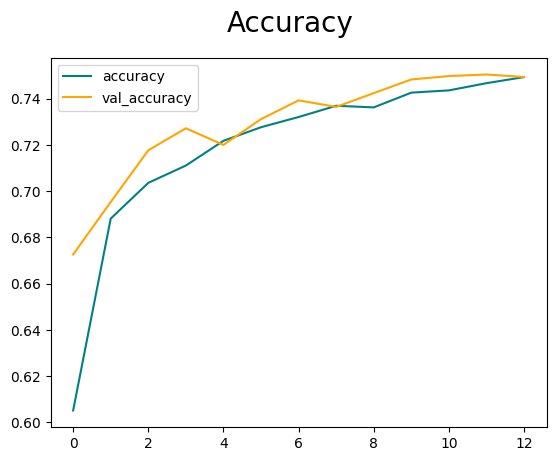

In [88]:
fig = plt.figure()
plt.plot(history.history['accuracy'], color='teal', label='accuracy')
plt.plot(history.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

In [89]:
def compute_iou(y_true, y_pred, class_label=1):
    intersection = np.logical_and(y_true == class_label, y_pred == class_label).sum()
    union = np.logical_or(y_true == class_label, y_pred == class_label).sum()
    iou = intersection / union if union != 0 else 0
    return iou

In [90]:
def compute_precision(y_true, y_pred, class_label=1):
    true_positive = np.logical_and(y_true == class_label, y_pred == class_label).sum()
    predicted_positive = (y_pred == class_label).sum()
    precision = true_positive / predicted_positive if predicted_positive != 0 else 0
    return precision

In [91]:
def compute_recall(y_true, y_pred, class_label=1):
    true_positive = np.logical_and(y_true == class_label, y_pred == class_label).sum()
    actual_positive = (y_true == class_label).sum()
    recall = true_positive / actual_positive if actual_positive != 0 else 0
    return recall

In [92]:
def compute_f1_score(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

In [93]:
new_model= load_model("E:/Msa/pattern recognition/Project/Water Bodies Code/model_saved/modell-12-0.7504.keras")

In [94]:
test_labels[5]

array([[[0.96862745],
        [0.98823529],
        [1.        ],
        ...,
        [1.        ],
        [0.99215686],
        [0.98431373]],

       [[0.99215686],
        [0.95294118],
        [0.94901961],
        ...,
        [1.        ],
        [0.99215686],
        [0.98431373]],

       [[0.96078431],
        [0.67058824],
        [0.47843137],
        ...,
        [1.        ],
        [0.99215686],
        [0.98431373]],

       ...,

       [[0.97647059],
        [0.98431373],
        [0.98431373],
        ...,
        [0.98039216],
        [0.97647059],
        [0.96078431]],

       [[0.97647059],
        [0.98431373],
        [0.98039216],
        ...,
        [0.97254902],
        [0.98431373],
        [0.98431373]],

       [[0.92156863],
        [0.94509804],
        [0.97647059],
        ...,
        [1.        ],
        [1.        ],
        [1.        ]]])

In [95]:
predictions = new_model.predict(test_images)
binary_prediction = (predictions > 0.5).astype(int)
predictions = binary_prediction.astype('float32')


iou_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for i in range(len(test_labels)):
    y_true = test_labels[i].squeeze()  # Squeeze to remove extra dimensions
    y_pred = predictions[i]
    y_pred = np.squeeze(y_pred)
    
    iou = compute_iou(y_true, y_pred, class_label=1)
    precision = compute_precision(y_true, y_pred, class_label=1)
    recall = compute_recall(y_true, y_pred, class_label=1)
    f1_score = compute_f1_score(precision, recall)

    iou_scores.append(iou)
    precision_scores.append(precision)
    recall_scores.append(recall)
    f1_scores.append(f1_score)

# Compute average scores
avg_iou = np.mean(iou_scores)
avg_precision = np.mean(precision_scores)
avg_recall = np.mean(recall_scores)
avg_f1= np.mean(f1_scores)

avg_iou,avg_precision,avg_recall,avg_f1

12/12 [==============================] - 2s 143ms/step


(0.5481217499511041, 0.6392449592555078, 0.7851568928477094, 0.669785705243771)

In [96]:
y_true.shape,y_pred.shape

((128, 128), (128, 128))

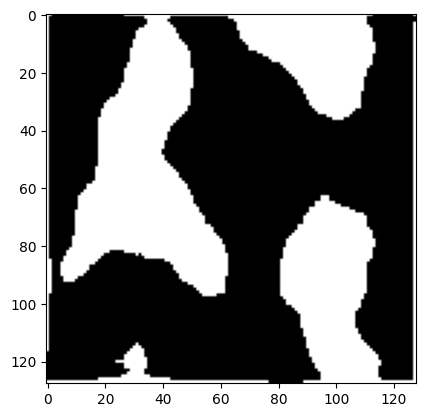

In [97]:
plt.imshow(predictions[4], cmap='gray')
plt.show()

In [101]:
print(len(test_images))

355


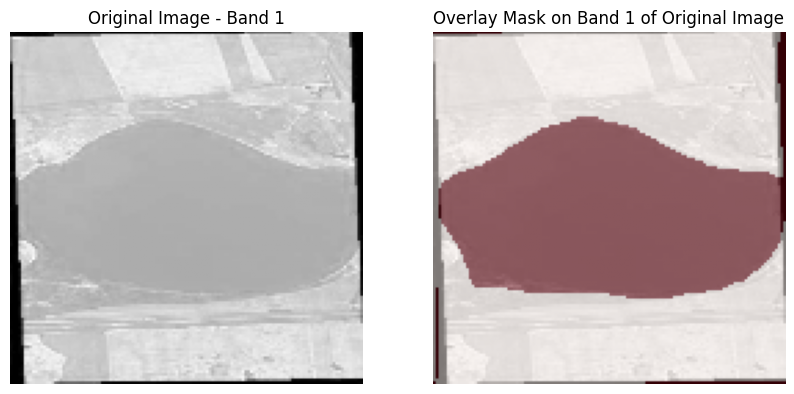

In [105]:
plt.figure(figsize=(10, 5))

# Plot the first band of the original image
plt.subplot(1, 2, 1)
plt.imshow(test_images[350][:, :, 0], cmap='gray')
plt.title('Original Image - Band 1')
plt.axis('off')

# Plot the overlay mask on the same image
plt.subplot(1, 2, 2)
plt.imshow(test_images[350][:, :, 0], cmap='gray') #(R,C,Dimentions)
plt.imshow(predictions[350], cmap='Reds', alpha=0.5)
plt.title('Overlay Mask on Band 1 of Original Image')
plt.axis('off')

plt.show()